<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/architectures/cnn/experiment_cnn_and_efficientnet_image_classification_cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Resources

### Neural Network Architecture

Input Image (32x32x3)

↓

Conv2D + ReLU

↓

Batch Normalization

↓

MaxPooling

↓

Dropout

↓

Conv2D + ReLU

↓

Batch Normalization

↓

MaxPooling

↓

Dropout

↓

Conv2D + ReLU

↓

Flatten

↓

Dense + ReLU

↓

Dropout

↓

Output Layer + Softmax

### Mathematical Foundation

#### Convolution Operation

$$\quad S(i,j)=(X*K)(i,j)=\sum_m\sum_n X(i-m,j-n)K(m,n)$$

CNN learns filters automatically.

#### ReLU Activation

$$\quad f(x)=\max(0,x)$$

#### Max Pooling

$$\quad P(i,j)=\max(X_{window})$$

#### Softmax Output

$$\quad \text{Softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}$$

#### Cross Entropy Loss

$$\quad L=-\sum y_i\log(\hat{y}_i)$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

Load Dataset

Using built-in CIFAR-10 dataset.

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Normalize Images

CNN trains faster with normalized pixels.

In [ ]:
X_train = X_train / 255.0

X_test = X_test / 255.0

One-Hot Encoding

In [ ]:
y_train = to_categorical(y_train, 10)

y_test = to_categorical(y_test, 10)

Visualize Dataset

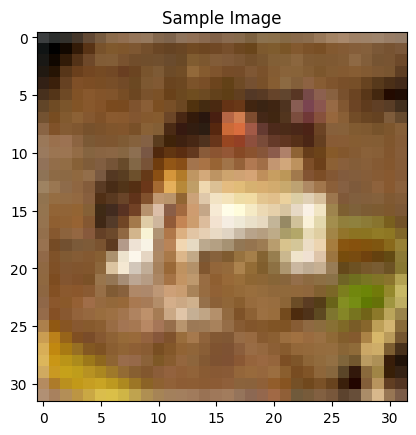

In [ ]:
plt.imshow(X_train[0])

plt.title("Sample Image")

plt.show()

Build CNN Architecture

In [ ]:
model = Sequential()

# ====================================================
# BLOCK 1
# ====================================================

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same",
        input_shape=(32, 32, 3)
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2, 2))
)

model.add(Dropout(0.25))

# ====================================================
# BLOCK 2
# ====================================================

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2, 2))
)

model.add(Dropout(0.25))

# ====================================================
# BLOCK 3
# ====================================================

model.add(
    Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    )
)

model.add(BatchNormalization())

model.add(
    MaxPooling2D((2, 2))
)

model.add(Dropout(0.25))

# ====================================================
# FLATTEN
# ====================================================

model.add(Flatten())

# ====================================================
# DENSE LAYER
# ====================================================

model.add(
    Dense(
        256,
        activation="relu"
    )
)

model.add(Dropout(0.5))

# ====================================================
# OUTPUT LAYER
# ====================================================

model.add(
    Dense(
        10,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile CNN

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

CNN Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

Train CNN

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.3725 - loss: 1.7541 - val_accuracy: 0.4119 - val_loss: 1.8301
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4891 - loss: 1.4153 - val_accuracy: 0.5168 - val_loss: 1.3989
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5483 - loss: 1.2590 - val_accuracy: 0.5625 - val_loss: 1.3021
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5957 - loss: 1.1481 - val_accuracy: 0.5709 - val_loss: 1.2734
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6255 - loss: 1.0776 - val_accuracy: 0.6286 - val_loss: 1.0843
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6479 - loss: 1.0101 - val_accuracy: 0.6399 - val_loss: 1.1189
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6683 - loss: 0.9547 - val_accuracy: 0.7118 - val_loss: 0.8330
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6831 - loss: 0.9110 - val_accuracy: 0

Evaluate CNN

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8064 - loss: 0.5968
Test Accuracy: 0.8064000010490417


Make Predictions

In [ ]:
predictions = model.predict(X_test)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(predicted_classes[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
[3 8 8 0 6 6 1 6 3 1]


Actual Labels

In [ ]:
actual_classes = np.argmax(
    y_test,
    axis=1
)

print(actual_classes[:10])

[3 8 8 0 6 6 1 6 3 1]


Visualize Predictions

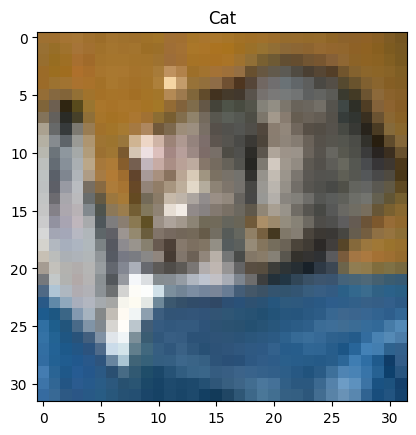

In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

plt.imshow(X_test[0])

plt.title(
    class_names[predicted_classes[0]]
)

plt.show()

Plot Accuracy Curves

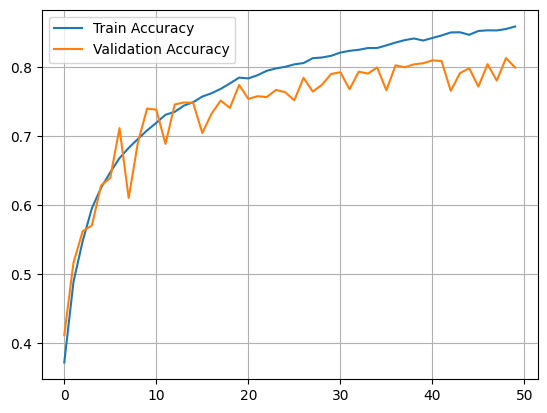

In [ ]:
plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

Save CNN Model

In [ ]:
model.save("cnn_image_classifier.keras")

What Makes Modern CNNs Better?

The previous CNN lacked:


*   residual connections
*   transfer learning
*   pretrained feature extraction
*   advanced normalization
*   scaling optimization
*   attention mechanisms

Modern systems use:


*   pretrained networks
*   deep residual learning
*   massive feature reuse
*   transfer learning


BEST PRACTICAL APPROACH TODAY

For most real-world classification tasks:

Transfer Learning + EfficientNet/ResNet

This massively outperforms training CNNs from scratch.

BEST INDUSTRY-STYLE IMAGE CLASSIFIER

Using:

TensorFlow,
Keras,
Transfer Learning,
EfficientNet

Why EfficientNet?

EfficientNet:

*   achieves very high accuracy
*   uses fewer parameters
*   trains faster
*   scales efficiently
*   widely used in production

INDUSTRY-GRADE CNN ARCHITECTURE

Input Image

↓

Pretrained EfficientNetB0

↓

Global Average Pooling

  ↓

Dropout

  ↓
  
Dense Layer

  ↓

Softmax Output

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

Load Dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

Normalize Images

In [ ]:
X_train = X_train / 255.0

X_test = X_test / 255.0

One-Hot Encoding

In [ ]:
y_train = to_categorical(y_train, 10)

y_test = to_categorical(y_test, 10)

Load Pretrained EfficientNet

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze Pretrained Layers

In [ ]:
base_model.trainable = False

Build Advanced Classifier

In [ ]:
inputs = Input(shape=(32, 32, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    10,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

Compile Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Learning Rate Scheduler

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 36ms/step - accuracy: 0.1015 - loss: 2.3083 - val_accuracy: 0.0999 - val_loss: 2.3025 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.0999 - loss: 2.3028 - val_accuracy: 0.0952 - val_loss: 2.3028 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1000 - loss: 2.3030 - val_accuracy: 0.0980 - val_loss: 2.3027 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1001 - loss: 2.3027 - val_accuracy: 0.0980 - val_loss: 2.3028 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.0990 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3028 - learning_rate: 5.0000e-04
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0993 - loss: 2.3027 - val_accuracy: 0.0952 - val_loss: 2.3028 - learning_rate: 5.0000e-04
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1004 - lo

Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.1009 - loss: 2.3025
Test Accuracy: 0.10090000182390213


Fine-Tuning (Advanced)

Now unfreeze deeper layers.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

Recompile with Lower LR

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Fine-Tune Model

In [ ]:
history_finetune = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.1018 - loss: 2.5555 - val_accuracy: 0.0952 - val_loss: 2.3038
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1007 - loss: 2.3854 - val_accuracy: 0.0952 - val_loss: 2.3031
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1032 - loss: 2.3429 - val_accuracy: 0.0952 - val_loss: 2.3031
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1020 - loss: 2.3275 - val_accuracy: 0.0952 - val_loss: 2.3028
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.1041 - loss: 2.3192 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1049 - loss: 2.3148 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.1057 - loss: 2.3107 - val_accuracy: 0.0952 - val_loss: 2.3027
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1063 - loss: 2.3079 - val_accur